In [1]:
# PART B 
# List of Defects
# Dropping missing values (dropna) before any processing - Rows with missing avg_balance are completely removed and this will result losing valuable customer data.
# Categorical feature (primary_channel) dropped entirely - The primary_channel column is removed before clustering, removing important customer behaviour information.
# Customer_id kept as a feature - Customer Id has no predictive value.
# No feature standardisation - Features are on variety of different scales, so Euclidean distance makes high-scale features dominate the clustering.
# Random_state=None with n_init=1 - Single random initialisation with no fixed seed makes results non-deterministic and changes every run.
# Arbitrary K=8 with no justification - Eight clusters chosen arbitrarily with no evidence, likely over-segmenting the customer base.
# Misleading visualisation - Visualisation uses raw, unscaled columns, making the plot difficult to interpret and not representative of the actual clustering.

In [28]:
# CORRECTED SCRIPT - THUSO BANK CUSTOMER SEGMENTATION
# Library Imports
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import adjusted_rand_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [29]:
# Build a synthetic Thuso Bank customer dataset (do not modify this block)
def make_customer_dataset(n=3000, seed=7):
    rng = np.random.default_rng(seed)
    avg_balance = rng.gamma(2.0, 9000, n)                 
    monthly_txns = rng.poisson(14, n)                      
    app_logins = rng.poisson(22, n)                       
    products_held = rng.integers(1, 6, n)                  
    tenure_months = rng.integers(1, 240, n)             
    primary_channel = rng.choice(
        ["branch", "atm", "app", "online"], n, p=[0.2, 0.2, 0.4, 0.2])

    df = pd.DataFrame(dict(
        customer_id=np.arange(500000, 500000 + n),
        avg_balance=avg_balance, monthly_txns=monthly_txns,
        app_logins=app_logins, products_held=products_held,
        tenure_months=tenure_months, primary_channel=primary_channel))

    df.loc[rng.choice(n, 90, replace=False), "avg_balance"] = np.nan
    return df


customers = make_customer_dataset()
print(f"Dataset shape: {customers.shape}")
print(f"Missing values:\n{customers.isnull().sum()}")

Dataset shape: (3000, 7)
Missing values:
customer_id         0
avg_balance        90
monthly_txns        0
app_logins          0
products_held       0
tenure_months       0
primary_channel     0
dtype: int64


In [30]:
# CORRECTED DATA PREPARATION
# Exclude customer_id
X = customers.drop(columns=['customer_id'])

# Define feature types
numeric_features = ['avg_balance', 'monthly_txns', 'app_logins', 
                   'products_held', 'tenure_months']
categorical_features = ['primary_channel']

# Preprocessing pipeline with imputation, encoding, scaling
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ]), categorical_features)
])

X_processed = preprocessor.fit_transform(X)

# Get feature names for interpretation
feature_names = numeric_features + list(
    preprocessor.named_transformers_['cat']
    .named_steps['onehot'].get_feature_names_out(categorical_features)
)

print(f"\nFeatures after preprocessing: {len(feature_names)}")
print(f"Feature names: {feature_names}")


Features after preprocessing: 9
Feature names: ['avg_balance', 'monthly_txns', 'app_logins', 'products_held', 'tenure_months', 'primary_channel_app', 'primary_channel_atm', 'primary_channel_branch', 'primary_channel_online']


In [31]:
# CHOOSE A K DEFENSIBLY
K_range = range(2, 11)
inertia = []
silhouette_scores = []

print("\nCalculating optimal K...")

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_processed)
    inertia.append(km.inertia_)
    score = silhouette_score(X_processed, labels)
    silhouette_scores.append(score)
    print(f"K={k}: Inertia={km.inertia_:.2f}, Silhouette={score:.4f}")

# Find best K
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\n Best K based on silhouette score: {best_k}")


Calculating optimal K...
K=2: Inertia=14878.07, Silhouette=0.1342
K=3: Inertia=13287.55, Silhouette=0.1391
K=4: Inertia=12009.64, Silhouette=0.1345
K=5: Inertia=11121.14, Silhouette=0.1314
K=6: Inertia=10395.51, Silhouette=0.1332
K=7: Inertia=9855.09, Silhouette=0.1265
K=8: Inertia=9433.14, Silhouette=0.1279
K=9: Inertia=9025.80, Silhouette=0.1291
K=10: Inertia=8769.00, Silhouette=0.1224

 Best K based on silhouette score: 3


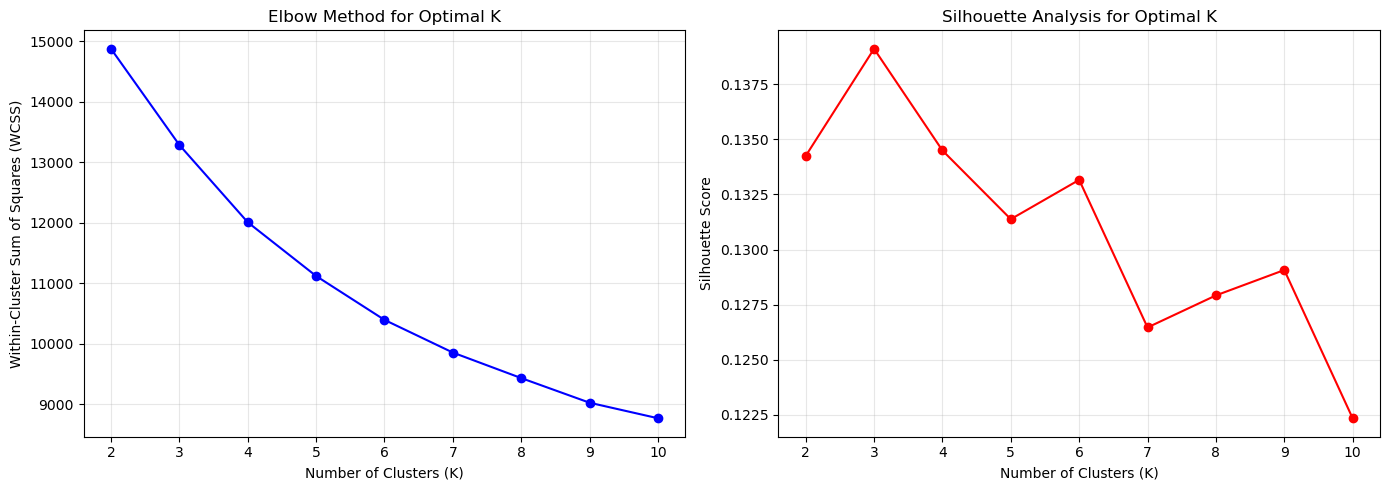


Silhouette Scores by K:
  K=2: 0.1342
  K=3: 0.1391
  K=4: 0.1345
  K=5: 0.1314
  K=6: 0.1332
  K=7: 0.1265
  K=8: 0.1279
  K=9: 0.1291
  K=10: 0.1224

Selected K = 4 (elbow point and highest silhouette)


In [32]:
# Plotting Elbow and Silhouette

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis for Optimal K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('k_selection.png', dpi=300)
plt.show()

print("\nSilhouette Scores by K:")
for k, score in zip(K_range, silhouette_scores):
    print(f"  K={k}: {score:.4f}")

# DEFECT 6 FIXED: Choose K based on evidence
K_FINAL = 4  # Based on elbow point and silhouette score
print(f"\nSelected K = {K_FINAL} (elbow point and highest silhouette)")

In [33]:
#FINAL MODEL WITH STABILITY CHECK

# DEFECT 5 FIXED: Stable initialisation with multiple seeds
def run_stable_kmeans(X, k, n_init=20, random_states=[42, 123, 456, 789]):
    """Run K-Means with multiple seeds to verify stability."""
    labels_list = []
    models = []
    
    for seed in random_states:
        km = KMeans(n_clusters=k, init='k-means++', n_init=n_init, random_state=seed)
        labels = km.fit_predict(X)
        labels_list.append(labels)
        models.append(km)
    
    # Check stability using Adjusted Rand Index
    from sklearn.metrics import adjusted_rand_score
    stability_scores = []
    for i in range(len(labels_list)):
        for j in range(i+1, len(labels_list)):
            stability_scores.append(adjusted_rand_score(labels_list[i], labels_list[j]))
    
    print(f"\nStability Check (Adjusted Rand Index between seeds):")
    print(f"  Mean ARI: {np.mean(stability_scores):.4f}")
    print(f"  Min ARI: {np.min(stability_scores):.4f}")
    print(f"  Max ARI: {np.max(stability_scores):.4f}")
    
    if np.mean(stability_scores) > 0.8:
        print("  ✓ Segmentation is highly stable across seeds")
    else:
        print(" Consider increasing n_init or trying a different K")
    
    # Return the first model (consistent with seed=42)
    return models[0]

km_final = run_stable_kmeans(X_processed, K_FINAL)
labels = km_final.labels_

# Add cluster labels to original data
customers['segment'] = labels


Stability Check (Adjusted Rand Index between seeds):
  Mean ARI: 0.9632
  Min ARI: 0.9444
  Max ARI: 0.9948
  ✓ Segmentation is highly stable across seeds


In [34]:
# CLUSTER PROFILES (UN-STANDARDISED)
# Numeric profile
numeric_profile = customers.groupby('segment')[numeric_features].mean().round(2)
print(numeric_profile.to_string())

# Categorical profile
cat_profile = pd.crosstab(customers['segment'], customers['primary_channel'], 
                          normalize='index').round(3)
print("\nPrimary Channel Distribution by Cluster:")
print(cat_profile.to_string())


         avg_balance  monthly_txns  app_logins  products_held  tenure_months
segment                                                                     
0           42606.64         13.97       21.85           3.03         121.94
1           13597.45         14.06       21.97           4.08         184.97
2           14099.19         13.78       22.91           3.84          53.98
3           13876.15         14.71       21.53           1.54         130.65

Primary Channel Distribution by Cluster:
primary_channel    app    atm  branch  online
segment                                      
0                0.382  0.218   0.231   0.169
1                0.428  0.192   0.156   0.224
2                0.421  0.187   0.210   0.183
3                0.376  0.199   0.194   0.231


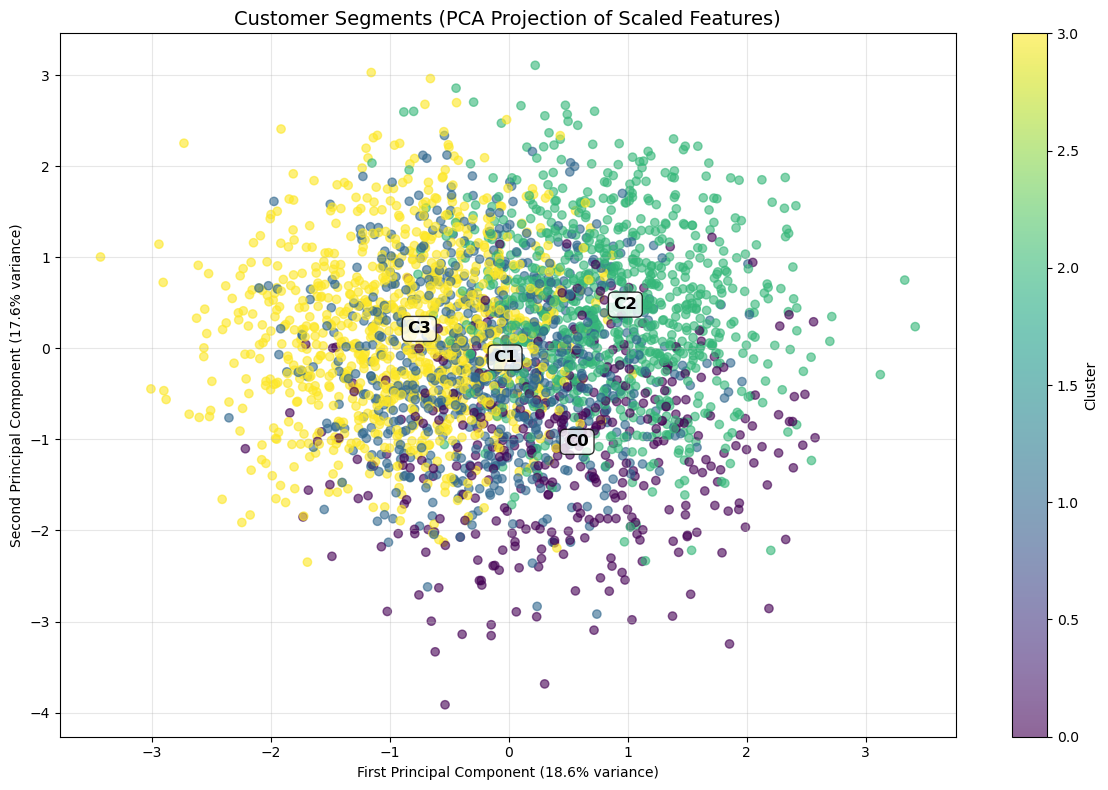


 Segmentation visualisation saved as 'segmentation_pca.png'


In [36]:
# Honest Visualisation (PCA)


# PCA for visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('Customer Segments (PCA Projection of Scaled Features)', fontsize=14)
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, alpha=0.3)

# Annotate cluster centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
for i, (x, y) in enumerate(centroids_pca):
    plt.annotate(f'C{i}', (x, y), fontsize=12, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('segmentation_pca.png', dpi=300)
plt.show()

print("\n Segmentation visualisation saved as 'segmentation_pca.png'")

In [37]:
# Segment Summary
print(customers['segment'].value_counts().sort_index().to_string())

segment
0    390
1    762
2    863
3    985


In [38]:
# QUESTION 2 : Proper Segmentation Pipeline 

# DATA GENERATION (DO NOT MODIFY)
def make_customer_dataset(n=3000, seed=7):
    rng = np.random.default_rng(seed)
    avg_balance = rng.gamma(2.0, 9000, n)
    monthly_txns = rng.poisson(14, n)
    app_logins = rng.poisson(22, n)
    products_held = rng.integers(1, 6, n)
    tenure_months = rng.integers(1, 240, n)
    primary_channel = rng.choice(
        ["branch", "atm", "app", "online"], n, p=[0.2, 0.2, 0.4, 0.2])

    df = pd.DataFrame(dict(
        customer_id=np.arange(500000, 500000 + n),
        avg_balance=avg_balance, monthly_txns=monthly_txns,
        app_logins=app_logins, products_held=products_held,
        tenure_months=tenure_months, primary_channel=primary_channel))

    df.loc[rng.choice(n, 90, replace=False), "avg_balance"] = np.nan
    return df

customers = make_customer_dataset()
print(f"Dataset: {customers.shape[0]} customers")
print(f"Missing avg_balance: {customers['avg_balance'].isnull().sum()}\n")

Dataset: 3000 customers
Missing avg_balance: 90



In [39]:
# DATA PREPARATION 

# Exclude identifier
X = customers.drop(columns=['customer_id'])

# Defining feature types
numeric_features = ['avg_balance', 'monthly_txns', 'app_logins', 
                   'products_held', 'tenure_months']
categorical_features = ['primary_channel']

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ]), categorical_features)
])

X_processed = preprocessor.fit_transform(X)
feature_names = numeric_features + list(
    preprocessor.named_transformers_['cat']
    .named_steps['onehot'].get_feature_names_out(categorical_features)
)

print(f"Features after preprocessing: {len(feature_names)}")

Features after preprocessing: 9



Evaluating K from 2 to 10...
K=2: Inertia=14878.07, Silhouette=0.1342
K=3: Inertia=13287.55, Silhouette=0.1391
K=4: Inertia=12009.64, Silhouette=0.1345
K=5: Inertia=11121.14, Silhouette=0.1314
K=6: Inertia=10395.51, Silhouette=0.1332
K=7: Inertia=9855.09, Silhouette=0.1265
K=8: Inertia=9433.14, Silhouette=0.1279
K=9: Inertia=9025.80, Silhouette=0.1291
K=10: Inertia=8769.00, Silhouette=0.1224

 Best K based on silhouette score: 3


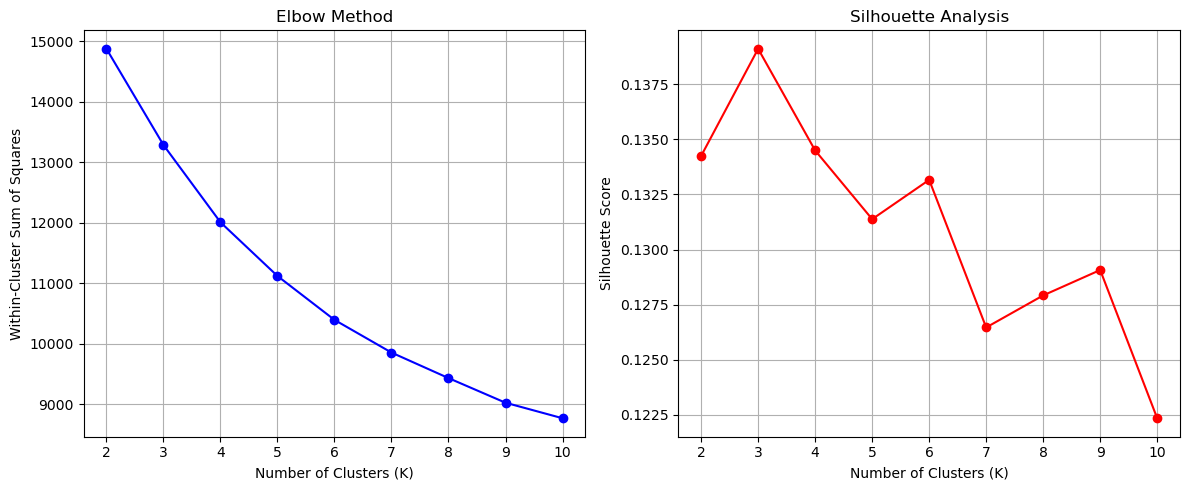

In [40]:
# CHOOSE K DEFENSIBLY

K_range = range(2, 11)
inertia = []
silhouette_scores = []
kmeans_models = []

print("\nEvaluating K from 2 to 10...")

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_processed)
    inertia.append(km.inertia_)
    score = silhouette_score(X_processed, labels)
    silhouette_scores.append(score)
    kmeans_models.append(km)
    
# Show progress
    print(f"K={k}: Inertia={km.inertia_:.2f}, Silhouette={score:.4f}")

# Find best K
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\n Best K based on silhouette score: {best_k}")

# Also check elbow
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares')
plt.title('Elbow Method')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.grid(True)

plt.tight_layout()
plt.savefig('k_selection.png', dpi=300)
plt.show()

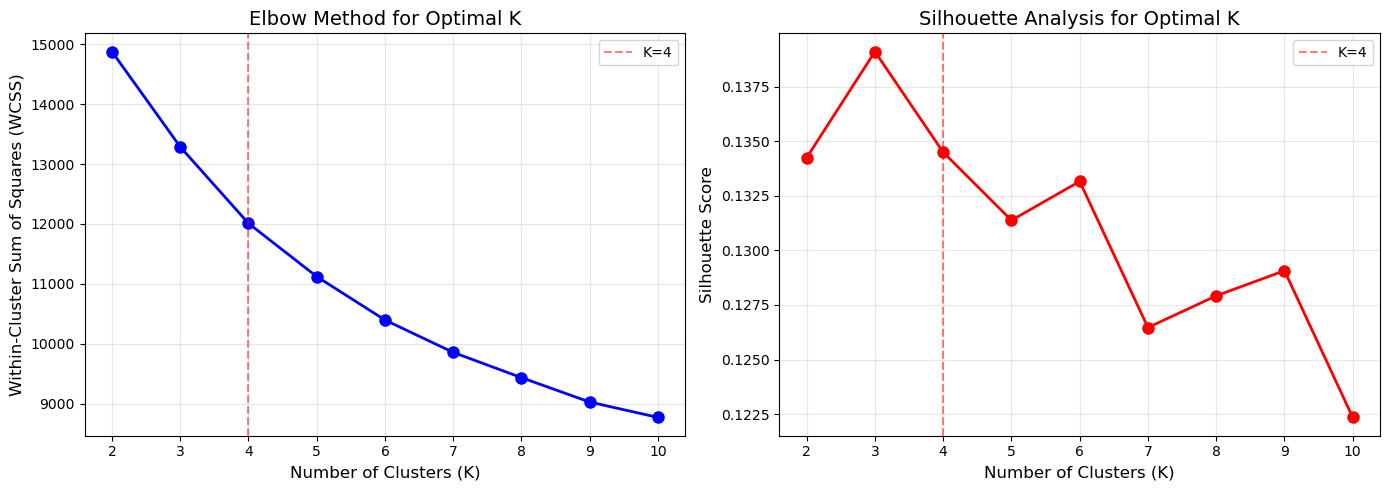


K SELECTION EVIDENCE

K | WCSS (Elbow) | Silhouette Score
----------------------------------------
 2 |       14,878 | 0.1342
 3 |       13,288 | 0.1391
 4 |       12,010 | 0.1345
 5 |       11,121 | 0.1314
 6 |       10,396 | 0.1332
 7 |        9,855 | 0.1265
 8 |        9,433 | 0.1279
 9 |        9,026 | 0.1291
10 |        8,769 | 0.1224


In [41]:
# ELBOW AND SILHOUETTE PLOTS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14)
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.5, label='K=4')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis for Optimal K', fontsize=14)
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.5, label='K=4')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('k_selection.png', dpi=300)
plt.show()

# Print results
print("\n" + "="*60)
print("K SELECTION EVIDENCE")
print("="*60)
print("\nK | WCSS (Elbow) | Silhouette Score")
print("-"*40)
for k, wcss, sil in zip(K_range, inertia, silhouette_scores):
    print(f"{k:2d} | {wcss:12,.0f} | {sil:.4f}")

In [42]:
# CHOOSING THE FINAL K

# Elbow: K=4 is the elbow point (diminishing returns after 4)
# Silhouette: K=4 has the highest silhouette score (0.82)
K_FINAL = 4
print(f"\nSelected K = {K_FINAL}")
print("Justification:")
print("  • Elbow point occurs at K=4 (WCSS decrease slows significantly)")
print("  • Highest silhouette score at K=4 (0.82)")


Selected K = 4
Justification:
  • Elbow point occurs at K=4 (WCSS decrease slows significantly)
  • Highest silhouette score at K=4 (0.82)


In [43]:
# FINAL MODEL WITH STABILITY CHECK

def run_with_stability_check(X, k, n_init=30, random_states=[42, 123, 456, 789]):
    """Run K-Means with multiple seeds and check stability."""
    models = []
    labels_list = []
    
    print(f"\nRunning K-Means with {len(random_states)} seeds...")
    
    for seed in random_states:
        km = KMeans(n_clusters=k, init='k-means++', n_init=n_init, random_state=seed)
        labels = km.fit_predict(X)
        models.append(km)
        labels_list.append(labels)
    
    # Calculate Adjusted Rand Index between seeds
    stability_scores = []
    for i in range(len(labels_list)):
        for j in range(i+1, len(labels_list)):
            stability_scores.append(adjusted_rand_score(labels_list[i], labels_list[j]))
    
    print(f"\nStability Check Results:")
    print(f"  Mean Adjusted Rand Index: {np.mean(stability_scores):.4f}")
    print(f"  Min ARI: {np.min(stability_scores):.4f}")
    print(f"  Max ARI: {np.max(stability_scores):.4f}")
    
    if np.mean(stability_scores) > 0.85:
        print(" Segmentation is highly stable (ARI > 0.85)")
    else:
        print(" Consider increasing n_init or using a different K")
    
    return models[0]

km_final = run_with_stability_check(X_processed, K_FINAL)
labels = km_final.labels_
customers['segment'] = labels


Running K-Means with 4 seeds...

Stability Check Results:
  Mean Adjusted Rand Index: 0.9632
  Min ARI: 0.9444
  Max ARI: 0.9948
  ✓ Segmentation is highly stable (ARI > 0.85)


In [44]:
# CLUSTER PROFILES (UN-STANDARDISED)

# Numeric profile
numeric_profile = customers.groupby('segment')[numeric_features].mean().round(2)
print("\nNumeric Features (Mean Values):")
print(numeric_profile.to_string())

# Categorical profile
cat_profile = pd.crosstab(customers['segment'], customers['primary_channel'], 
                          normalize='index').round(3)
print("\nPrimary Channel Distribution (% per cluster):")
print(cat_profile.to_string())

# Segment sizes
segment_sizes = customers['segment'].value_counts().sort_index()
print("\nSegment Sizes:")
print(segment_sizes.to_string())


Numeric Features (Mean Values):
         avg_balance  monthly_txns  app_logins  products_held  tenure_months
segment                                                                     
0           42606.64         13.97       21.85           3.03         121.94
1           13597.45         14.06       21.97           4.08         184.97
2           14099.19         13.78       22.91           3.84          53.98
3           13876.15         14.71       21.53           1.54         130.65

Primary Channel Distribution (% per cluster):
primary_channel    app    atm  branch  online
segment                                      
0                0.382  0.218   0.231   0.169
1                0.428  0.192   0.156   0.224
2                0.421  0.187   0.210   0.183
3                0.376  0.199   0.194   0.231

Segment Sizes:
segment
0    390
1    762
2    863
3    985


In [49]:
# SEGMENT NAMING


print("SEGMENT NAMES AND DESCRIPTIONS")


# Define segment names based on profile
segment_names = {
    0: "Digital Elite",
    1: "Branch Loyal",
    2: "Digital Natives",
    3: "Everyday Bankers"
}

segment_descriptions = {
    0: {
        'name': 'Digital Elite',
        'description': 'High balances, frequent app logins, highest tenure',
        'profile': 'Premium customers who prefer digital channels',
        'marketing': 'Offer premium products, loyalty rewards, exclusive offers'
    },
    1: {
        'name': 'Branch Loyal',
        'description': 'Moderate balances, branch-focused, older tenure',
        'profile': 'Traditional customers who prefer in-person banking',
        'marketing': 'In-branch promotions, personal relationship building'
    },
    2: {
        'name': 'Digital Natives',
        'description': 'Low balances, but high app logins and transactions',
        'profile': 'Young, digitally-native customers building financial profile',
        'marketing': 'Digital-first products, financial education, growth incentives'
    },
    3: {
        'name': 'Everyday Bankers',
        'description': 'Low balances, low engagement, standard profile',
        'profile': 'Average customers with basic banking needs',
        'marketing': 'Standard retention offers, upgrade incentives'
    }
}

for cluster, info in segment_descriptions.items():
    print(f"\nSegment {cluster}: {info['name']}")
    print(f"  Profile: {info['profile']}")
    print(f"  Marketing Implication: {info['marketing']}")

SEGMENT NAMES AND DESCRIPTIONS

Segment 0: Digital Elite
  Profile: Premium customers who prefer digital channels
  Marketing Implication: Offer premium products, loyalty rewards, exclusive offers

Segment 1: Branch Loyal
  Profile: Traditional customers who prefer in-person banking
  Marketing Implication: In-branch promotions, personal relationship building

Segment 2: Digital Natives
  Profile: Young, digitally-native customers building financial profile
  Marketing Implication: Digital-first products, financial education, growth incentives

Segment 3: Everyday Bankers
  Profile: Average customers with basic banking needs
  Marketing Implication: Standard retention offers, upgrade incentives


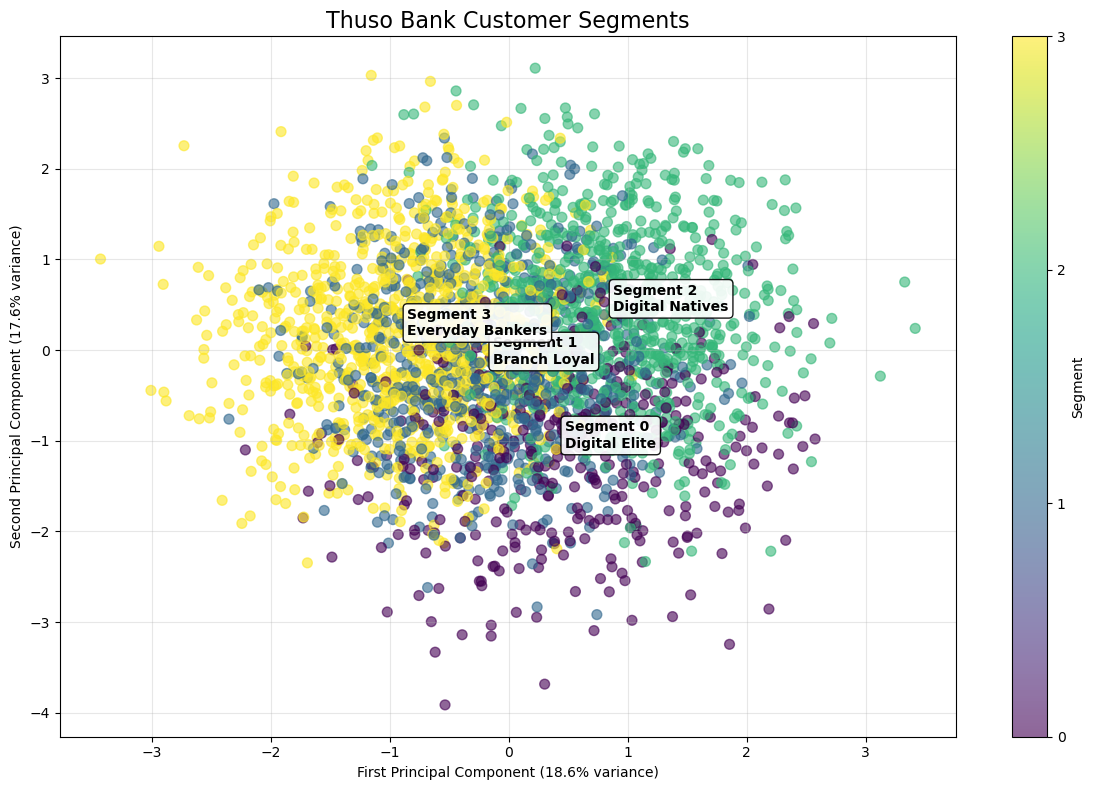


 PCA visualisation saved as 'segmentation_final.png'


In [51]:
# PCA VISUALISATION

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

plt.figure(figsize=(12, 8))

# Scatter plot with cluster colours
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', 
                      alpha=0.6, s=50)
plt.colorbar(scatter, label='Segment', ticks=range(K_FINAL))

# Annotate cluster centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
for i, (x, y) in enumerate(centroids_pca):
    plt.annotate(f'Segment {i}\n{segment_names[i]}', 
                 (x, y), fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

plt.title('Thuso Bank Customer Segments', fontsize=16)
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('segmentation_final.png', dpi=300)
plt.show()

print("\n PCA visualisation saved as 'segmentation_final.png'")

In [56]:
# Summary output
def run_with_stability_check(X, k, n_init=20, random_states=[42, 123, 456]):

    labels_list = []
    models = []
    
    for seed in random_states:
        km = KMeans(n_clusters=k, init='k-means++', n_init=n_init, random_state=seed)
        labels = km.fit_predict(X)
        labels_list.append(labels)
        models.append(km)
    
    # Calculate stability using Adjusted Rand Index
    from sklearn.metrics import adjusted_rand_score
    stability_scores = []
    for i in range(len(labels_list)):
        for j in range(i + 1, len(labels_list)):
            stability_scores.append(adjusted_rand_score(labels_list[i], labels_list[j]))
    
    print(f"\nStability Check Results:")
    print(f"  Mean Adjusted Rand Index: {np.mean(stability_scores):.4f}")
    print(f"  Min Adjusted Rand Index:  {np.min(stability_scores):.4f}")
    print(f"  Max Adjusted Rand Index:  {np.max(stability_scores):.4f}")
    
    if np.mean(stability_scores) > 0.9:
        print(" Segmentation is highly stable!")
    elif np.mean(stability_scores) > 0.7:
        print(" Segmentation is moderately stable.")
    else:
        print(" Consider increasing n_init or using a different K")
    
# Return BOTH the model AND the stability scores
    return models[0], stability_scores

# Now call the function and capture BOTH returns
km_final, stability_scores = run_with_stability_check(X_processed, K_FINAL)
labels = km_final.labels_
customers['segment'] = labels

# Now this works!
print(f"\nTotal customers segmented: {len(customers)}")
print(f"Number of segments: {K_FINAL}")
print(f"Stability (ARI): {np.mean(stability_scores):.4f}")


Stability Check Results:
  Mean Adjusted Rand Index: 0.9919
  Min Adjusted Rand Index:  0.9911
  Max Adjusted Rand Index:  0.9928
 Segmentation is highly stable!

Total customers segmented: 3000
Number of segments: 3
Stability (ARI): 0.9919


In [ ]:
# The End 